In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
with open("dano_dataset_travel.csv", "r", encoding="utf-8") as f:
    for i in range(2):
        print(f.readline())

order_online_payment_flg;account_rk;client_rk;order_rk;loyalty_program_type_nm;bundle_nm;order_type_cd;order_status_cd;party_first_order_dt;party_first_order_type_dt;free_cancel_booking_dttm;created_dttm;cancel_dttm;book_start_dttm;local_book_start_dttm;book_end_dttm;hotel_country;hotel_city;avia_dep_city;avia_arr_city;promo_code_discount_amt;loyalty_accrual_rub_amt;nominal_price_eur_amt;nominal_price_rub_amt;order_item_cnt;month_beginning_balance_rub;monthly_income_amt;suppress_email_flg;suppress_call_flg;bounce_cd;last_sms_success_flg;call_contact_6m_flg;call_contact_3m_flg;call_contact_1m_flg;good_email_address_flg;bad_email_address_flg;email_valid_flg;children_cnt;age;age_type_cd;parent_meeting_region_nm;delivery_region_category_cd;lvn_city_nm;lvn_state_nm;time_zone_delta_tm;time_zone_cd;last_used_product_cd;first_used_product_cd;mobile_phone_operator_nm;marital_status_cd;education_level_cd;birth_place;gender_cd;last_sms_dt;last_email_send_dt;last_session_dttm

1,0;209c833731e84d21

Получается разделитель - ;

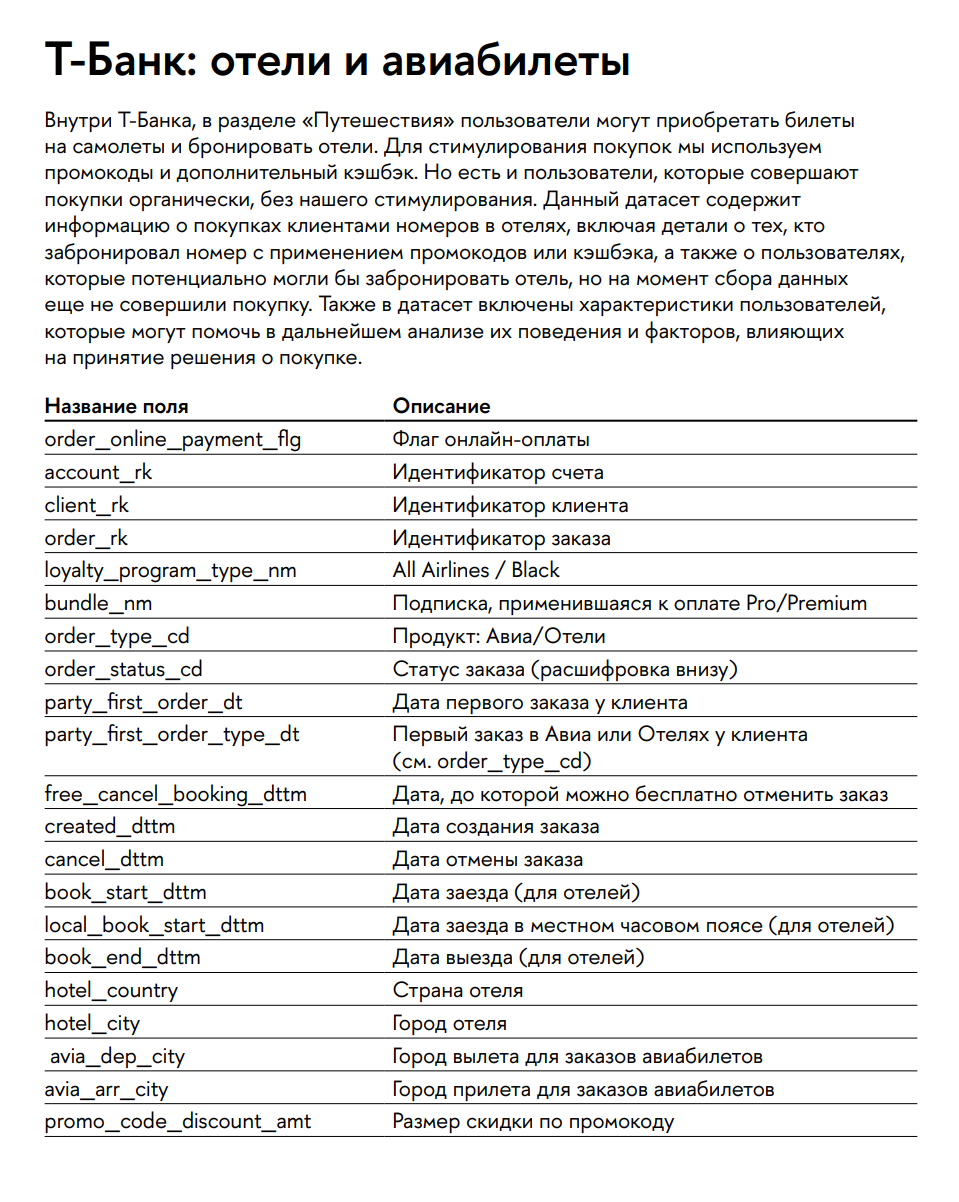
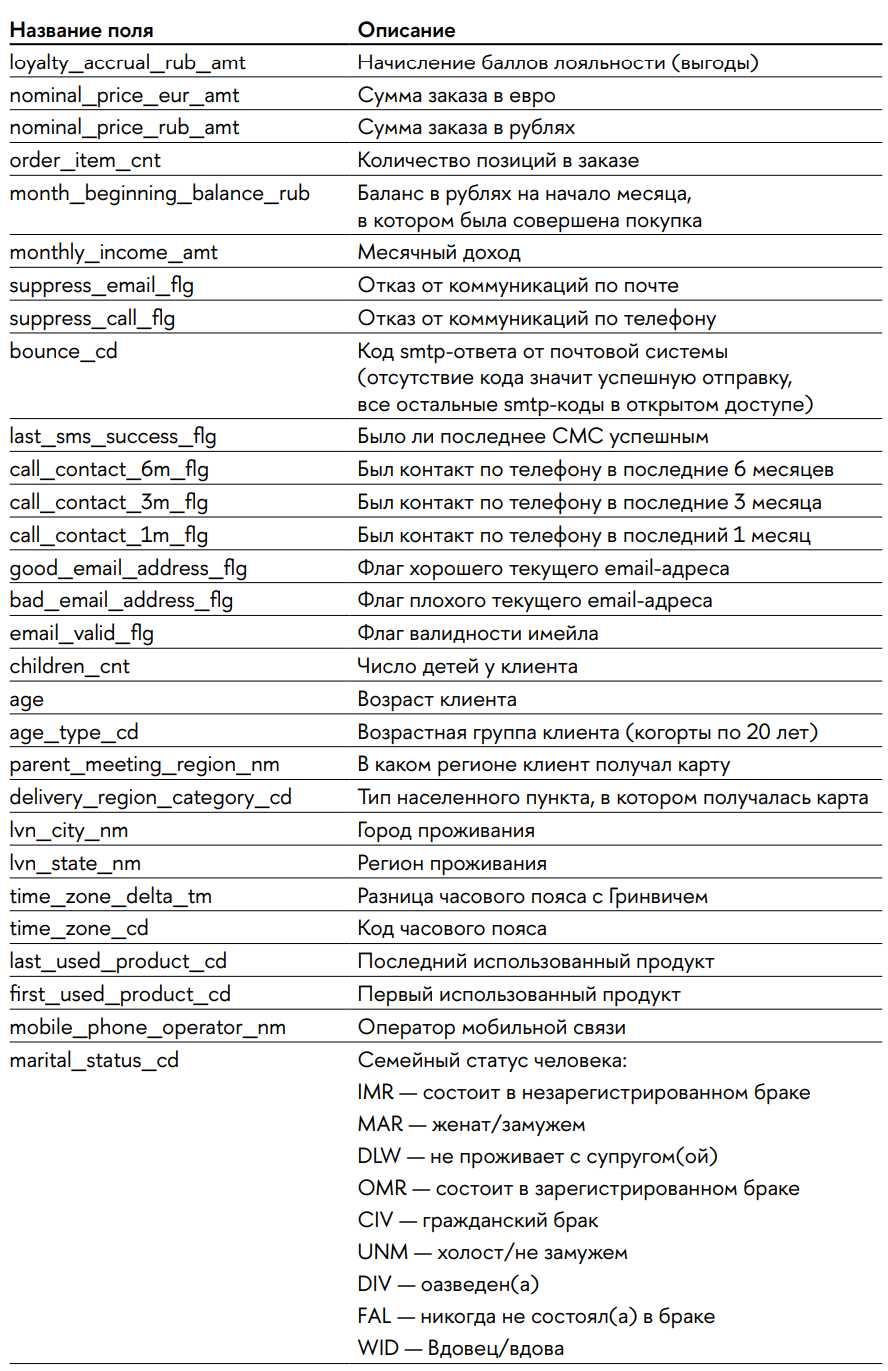
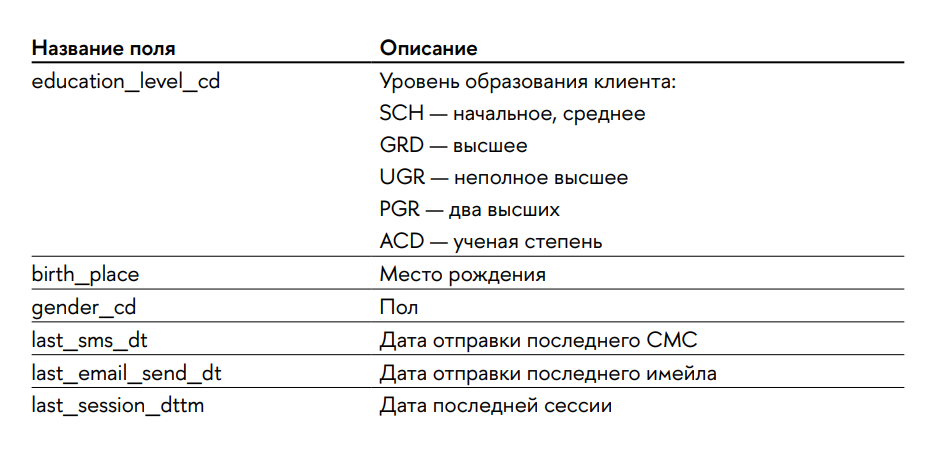

In [124]:
df = pd.read_csv("dano_dataset_travel.csv", sep=';')

C:\Users\Petr\AppData\Local\Temp\ipykernel_8876\1195759353.py:1: DtypeWarning: Columns (31,32,33,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dano_dataset_travel.csv", sep=';')


# Убираем пробельные символы по бокам и заменяем все текстовые аналоги NaN

In [156]:

for col in df.columns: 
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)


list_str_nan = ["", " ", "-", "—", "NaN", "nan", "NULL", "None", "N/A"]
df.replace(list_str_nan, pd.NA, inplace=True)

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  object 
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

In [158]:
nan_percent = df.isna().mean() * 100
print(nan_percent.sort_values())

suppress_email_flg               0.000000
time_zone_cd                     0.000000
time_zone_delta_tm               0.000000
delivery_region_category_cd      0.000000
email_valid_flg                  0.000000
bounce_cd                        0.000000
suppress_call_flg                0.000000
last_session_dttm                0.000000
account_rk                       0.000000
client_rk                        0.000000
order_rk                         0.000000
age                              0.000120
last_used_product_cd             0.000359
age_type_cd                      0.029667
mobile_phone_operator_nm         0.148336
last_sms_dt                      0.239133
last_sms_success_flg             0.239133
first_used_product_cd            0.294280
birth_place                      0.369286
gender_cd                        1.215042
party_first_order_dt             5.868019
order_type_cd                    5.868019
nominal_price_rub_amt            5.868019
order_online_payment_flg         5

In [159]:
count_unique = df.nunique().sort_values()
print(len(count_unique))
count_unique

56


cancel_dttm                         0
order_online_payment_flg            1
call_contact_1m_flg                 1
call_contact_3m_flg                 1
call_contact_6m_flg                 1
gender_cd                           2
email_valid_flg                     2
bad_email_address_flg               2
good_email_address_flg              2
last_sms_success_flg                2
bounce_cd                           2
suppress_call_flg                   2
suppress_email_flg                  2
order_type_cd                       2
delivery_region_category_cd         3
age_type_cd                         4
last_used_product_cd                4
education_level_cd                  5
marital_status_cd                   6
order_status_cd                     7
children_cnt                        8
first_used_product_cd               9
bundle_nm                           9
order_item_cnt                      9
time_zone_delta_tm                 12
time_zone_cd                       23
loyalty_prog

In [160]:
df.sample(10).T

,812325,162406,722698,726085,505284,382492,557416,51173,428877,293635
order_online_payment_flg,"1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0"
account_rk,b96a034270f4c99f0877b8f0b88cf33176c8d297fe61bc...,e09e43798b883a67b91208069da4b0ed332f3104eb210c...,378268c231810f1ae04b922782da9277238000e60735ec...,01d11edfe05158f76b736439a7958a27f9fe24acde29ec...,fce23b36c9261bc6e560f7bdb6a9f7aa64693679077345...,a4213df299ded3c1f826f91525d3d3e4d2169312f8285f...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,969502bb7815e6f64315e7505d073976ff744b1aab7aa4...,838585521c2701bcc3636c1eca27a7f537a2b02faced65...,a6872d4eb2582ad320ce283409995450bc829753dc4d03...
client_rk,c881e5eaec5ad61bfeade36452cc9b5d5c5944338c8139...,00d706ef461c832f7190a0b23fd7f70ad4ac537b7e1fa7...,995bde9b5ecf2d8abc5c179149a0d8a1c112ecce3fe61e...,0b49f44a1e7d1d206a89ddeef506d047a2e72b4f616542...,d977f74390cce6dfa533d5f95e9430926a8ee9b6b6d81b...,a36daf43385e6542bb5ca796893752eac6e981e0460100...,4b7441638de81d4ed68865cb2cea55244ee65a5d4adcf1...,e45d03e7cca64bb4c9d9c0336295845ab392965ada72d1...,ec2b64c05ad3cfb906fc4eab154ccd321274bb1ed603ec...,e53ee625de467adec514ff074588c018512bc2e84e0238...
order_rk,696f895391c00931af8e6d83334bf824b78bc0b5d72e90...,6ef795e1d661018fa210a171b218627c71441559ec9237...,e4992fdd1496cb079261a54eb9828dfca79d8fad11224a...,ee3be7b510d9d79d9b6c42baf42a97737f6bf56460bcf9...,3b965552b42fba91eb7d99fda24bb0271eb9b69b5534ee...,f89d08523ff15546f192d8ea274e9590b1a17e86706c9f...,4ac3b61e42632534812782a594a7c76de93e7193a542a1...,16d9ee40fce551e08d8a2b043e28f2ebffd8ab1f34bc09...,4042abfb968c923f7c33e5d52a80bfdb4b6fa4da40ba51...,d49ae9c1eaa0ec47213886d7dc03c18f0f2f545ab0b634...
loyalty_program_type_nm,Bravo,Tinkoff Black,All Airlines,Tinkoff Black Premium,All Airlines,NaN,NaN,Tinkoff Black,Tinkoff Black Premium,All Airlines
bundle_nm,NaN,NaN,NaN,Premium,NaN,Premium,NaN,Pro,NaN,Pro
order_type_cd,AIR,HOT,AIR,AIR,AIR,AIR,AIR,HOT,AIR,AIR
order_status_cd,SUC,NaN,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC
party_first_order_dt,2020-02-03,2019-03-10,2024-06-11,2023-07-24,2021-03-21,2022-02-25,2023-08-27,2023-04-10,2023-02-11,2021-12-01
party_first_order_type_dt,2020-02-03,2019-12-29,2024-06-11,2023-10-14,2021-03-21,2024-01-28,2023-08-27,2023-04-10,2024-03-30,2021-12-01


In [ ]:
![image.png](attachment:cf067ca3-3e67-4c7c-8c2f-babf145c2382.png)
![image.png](attachment:f955ea85-133e-4ef1-a5a0-aca3b194eaa3.png)

# Удаление мало заполненных столбцов


children_cnt                    13.905218
monthly_income_amt              19.482306
promo_code_discount_amt         26.322287
order_item_cnt                  26.389637
avia_dep_city                   26.397053
avia_arr_city                   26.397053
bundle_nm                       29.653993
marital_status_cd               37.688202
lvn_city_nm                     43.061686
loyalty_accrual_rub_amt         43.135376
education_level_cd              43.165163
book_end_dttm                   79.478382
hotel_city                      80.590905
hotel_country                   80.590905
free_cancel_booking_dttm        90.956267
last_email_send_dt              97.631643
bad_email_address_flg           97.631643
good_email_address_flg          97.631643
call_contact_3m_flg             99.967581
call_contact_1m_flg             99.967581
call_contact_6m_flg             99.967581
cancel_dttm                    100.000000

In [127]:
cols_to_drop = [
    "lvn_city_nm", "book_end_dttm", "hotel_city", "hotel_country", "last_email_send_dt", 
    "call_contact_1m_flg", "call_contact_3m_flg", "call_contact_6m_flg", "cancel_dttm", "good_email_address_flg", 
    "bad_email_address_flg", "free_cancel_booking_dttm"]

df2 = df.drop(columns=cols_to_drop)

In [128]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   order_online_payment_flg     786885 non-null  object
 1   account_rk                   835938 non-null  object
 2   client_rk                    835938 non-null  object
 3   order_rk                     835938 non-null  object
 4   loyalty_program_type_nm      754957 non-null  object
 5   bundle_nm                    588049 non-null  object
 6   order_type_cd                786885 non-null  object
 7   order_status_cd              779514 non-null  object
 8   party_first_order_dt         786885 non-null  object
 9   party_first_order_type_dt    786767 non-null  object
 10  created_dttm                 786885 non-null  object
 11  book_start_dttm              786885 non-null  object
 12  local_book_start_dttm        786885 non-null  object
 13  avia_dep_city 

In [129]:
nan_percent = df2.isna().mean() * 100
print(nan_percent.sort_values())

last_session_dttm               0.000000
suppress_call_flg               0.000000
email_valid_flg                 0.000000
delivery_region_category_cd     0.000000
time_zone_delta_tm              0.000000
suppress_email_flg              0.000000
time_zone_cd                    0.000000
order_rk                        0.000000
client_rk                       0.000000
account_rk                      0.000000
age                             0.000120
last_used_product_cd            0.000359
age_type_cd                     0.029667
mobile_phone_operator_nm        0.148336
last_sms_success_flg            0.239133
last_sms_dt                     0.239133
first_used_product_cd           0.294280
birth_place                     0.354691
gender_cd                       1.215042
order_online_payment_flg        5.868019
book_start_dttm                 5.868019
nominal_price_rub_amt           5.868019
nominal_price_eur_amt           5.868019
order_type_cd                   5.868019
party_first_orde

1) Процент пустых записей: 0.0
2) Количество пустых записей: 0
3) Количество уникальных записей: 2
4) Топ уникальных записей для bounce_cd
1    796263
0     39675
Name: count, dtype: int64:
5) Количество типов записей: bounce_cd
<class 'int'>    835938
Name: count, dtype: int64


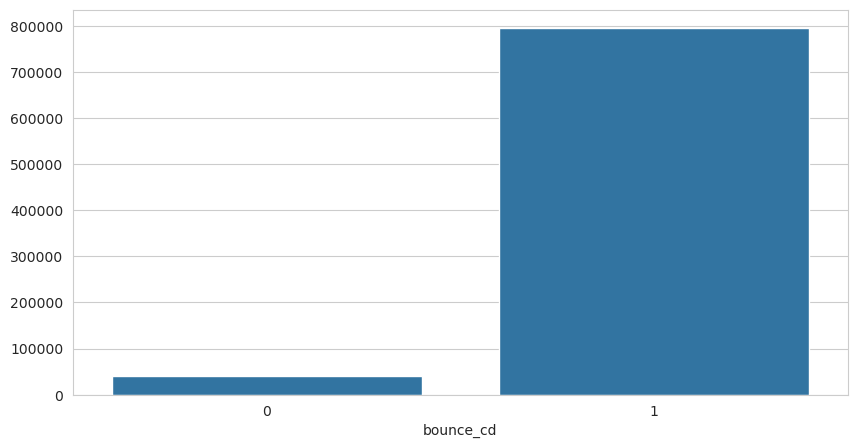

In [143]:
data_set = df2
column = "bounce_cd"
nan_percent = data_set[column].isna().mean() * 100
nan_count = data_set[column].isna().sum()
count_unique = data_set[column].nunique()
top_values = data_set[column].value_counts(dropna=False, ascending=False).head(count_unique if count_unique <= 10 else 10)
types = data_set[column].apply(type).value_counts()
print(f"1) Процент пустых записей: {nan_percent}")
print(f"2) Количество пустых записей: {nan_count}")
print(f"3) Количество уникальных записей: {count_unique}")
print(f"4) Топ уникальных записей для {top_values}:")
print(f"5) Количество типов записей: {types}")
with sns.axes_style("whitegrid"):
    plt.figure(figsize=(10,5))
    sns.barplot(
        y=top_values.values, 
        x=top_values.index)

bounce_cd - Код smtp-ответа от почтовой системы (отсутствие кода значит успешную отправку, все остальные smtp-коды в открытом доступе)
Тогда заменяем NaN на 1 (доставлено), а остльные занчения на 0 (не доставлено)

In [133]:
df2["bounce_cd"] = df2["bounce_cd"].apply(lambda x: 1 if pd.isna(x) else 0)

# Удаление всех NaN и работа с базой без пропусков

In [154]:
df3 = df2.dropna()
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128961 entries, 4 to 835921
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   order_online_payment_flg     128961 non-null  object
 1   account_rk                   128961 non-null  object
 2   client_rk                    128961 non-null  object
 3   order_rk                     128961 non-null  object
 4   loyalty_program_type_nm      128961 non-null  object
 5   bundle_nm                    128961 non-null  object
 6   order_type_cd                128961 non-null  object
 7   order_status_cd              128961 non-null  object
 8   party_first_order_dt         128961 non-null  object
 9   party_first_order_type_dt    128961 non-null  object
 10  created_dttm                 128961 non-null  object
 11  book_start_dttm              128961 non-null  object
 12  local_book_start_dttm        128961 non-null  object
 13  avia_dep_city      

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(12,5))
    ax = sns.histplot(data=df2, x='', hue='Sex', kde=True)
    ax.set(xlabel='Age',
           ylabel='Count pass.',
           title='Pass.(Age)'
    )

In [148]:
df2_ordered = df2[df2["order_online_payment_flg"].notna()]
df2_not_ordered = df2[df2["order_online_payment_flg"].isna()]

In [149]:
df2_ordered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 786885 entries, 0 to 835937
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   order_online_payment_flg     786885 non-null  object
 1   account_rk                   786885 non-null  object
 2   client_rk                    786885 non-null  object
 3   order_rk                     786885 non-null  object
 4   loyalty_program_type_nm      754957 non-null  object
 5   bundle_nm                    588049 non-null  object
 6   order_type_cd                786885 non-null  object
 7   order_status_cd              779514 non-null  object
 8   party_first_order_dt         786885 non-null  object
 9   party_first_order_type_dt    786767 non-null  object
 10  created_dttm                 786885 non-null  object
 11  book_start_dttm              786885 non-null  object
 12  local_book_start_dttm        786885 non-null  object
 13  avia_dep_city      

In [150]:
df2_not_ordered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49053 entries, 59 to 835908
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   order_online_payment_flg     0 non-null      object
 1   account_rk                   49053 non-null  object
 2   client_rk                    49053 non-null  object
 3   order_rk                     49053 non-null  object
 4   loyalty_program_type_nm      0 non-null      object
 5   bundle_nm                    0 non-null      object
 6   order_type_cd                0 non-null      object
 7   order_status_cd              0 non-null      object
 8   party_first_order_dt         0 non-null      object
 9   party_first_order_type_dt    0 non-null      object
 10  created_dttm                 0 non-null      object
 11  book_start_dttm              0 non-null      object
 12  local_book_start_dttm        0 non-null      object
 13  avia_dep_city                0 non